In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.5 MB/s eta 0:00:00


ADD the natural LLPS + protein xlxs file first. add pdb30 too


In [2]:
import pandas as pd
import numpy as np
from Bio.SeqUtils.ProtParam import ProteinAnalysis

In [3]:
# NOTE: max_colwidth=False is NOT just cosmetic here -- the sequence
# extraction step below uses df.to_string() to pull the sequence text
# out of a Series, and without this setting pandas truncates long
# strings with '...', corrupting every sequence longer than ~50 chars.
pd.set_option('display.max_columns', False)
pd.set_option('display.max_rows', 500)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [4]:
#loading the raw data "Natural Proteins Only"
df = pd.read_excel('/content/LLPS.xlsx')
print(f"[0] Raw LLPSDB entries loaded:                 {df.shape[0]}")

[0] Raw LLPSDB entries loaded:                 2143


In [5]:
# 1) KEEP ONLY SINGLE-PROTEIN SYSTEMS
#    Protein IDs are 5 chars for a single protein (e.g. 'p0001').
#    Multi-component IDs are longer (e.g. 'p0001+p0002').
#    We ALSO explicitly require 'Components type' == protein(1)
#    so we exclude protein+RNA / protein+DNA / protein+protein rows.
#    WHY: DeePhase only models proteins that phase separate on
#    their own (homotypically) -- not with an RNA/DNA/protein partner.
# ---------------------------------------------------------------
df = df[df['Protein ID'].str.len() == 5]
df = df[(df['Components type'] == 'protein(1)') | (df['Components type'] == 'Protein(1)')]
print(f"[1] After single-protein-system filter:        {df.shape[0]}")


[1] After single-protein-system filter:        1153


In [6]:
# ---------------------------------------------------------------
# only keep the naturally occuring protiens.
df = df[df['Protein type (N/D)'] == 'N']
print(f"[2] After natural-protein-only filter:         {df.shape[0]}")


[2] After natural-protein-only filter:         1153


In [7]:
# 3) DROP CONSTRUCTS THAT AREN'T THE PLAIN WILD-TYPE SEQUENCE
#    - Mutation != '-'   -> has point mutation(s)
#    - PTM != '-'        -> has a post-translational modification
#    - Repeat != '-'     -> is a tandem-repeat construct
#    - Pressure != '-'   -> experiment run at non-atmospheric pressure
#    WHY: mutations/PTMs/repeats change the sequence away from the
#    natural UniProt sequence, and non-atmospheric pressure is an
#    unusual extrinsic condition -- both would corrupt the
#    sequence<->phase-behavior mapping we're trying to learn.
# ---------------------------------------------------------------
df = df[df['Mutation'] == '-']
df = df[df['PTM'] == '-']
df = df[df['Repeat'] == '-']
df = df[df['Pressure'] == '-']
print(f"[3] After mutation/PTM/repeat/pressure filter:  {df.shape[0]}")


[3] After mutation/PTM/repeat/pressure filter:  739


In [8]:
#Choose only individual experiments
df = df[df['Phase diagram'].isna()]
print(f"[4] After phase-diagram-series filter:          {df.shape[0]}  <- paper reports 769")


[4] After phase-diagram-series filter:          682  <- paper reports 769


In [9]:
# 5) EXTRACT THE ACTUAL CONSTRUCT SEQUENCE
#    The 'Sequence' field stores a FASTA-like block (header line +
#    sequence line(s)). We split on newline and take everything
#    after the header to get the raw amino-acid string.
# ---------------------------------------------------------------
df['Extract_construct_sequence'] = df['Sequence'].str.split('\n').str[1:]
construct_sequences = []
for i in range(df.shape[0]):
    construct_sequences.append(
        df['Extract_construct_sequence'][i:i + 1]
        .to_string(index=False)
        .translate(str.maketrans({',': '', '[': '', ']': '', ' ': ''}))
    )
df['Construct_sequence'] = np.asarray(construct_sequences)
df = df.drop(columns=['Extract_construct_sequence'])

# Manually fix one w/v-formatted concentration entry the parser can't handle
df['Solute concentration'] = df['Solute concentration'].str.replace(
    '1:19 w/v 5HT1A', '0.05 mg/ml 5HT1A'
)
df = df[df['Construct_sequence'] != '']
print(f"[5] After removing empty-sequence rows:         {df.shape[0]}")


[5] After removing empty-sequence rows:         681


In [10]:

from Bio.SeqUtils.ProtParam import ProteinAnalysis
import re

# ---------------------------------------------------------------
# 6) PARSE THE SOLUTE CONCENTRATION INTO (VALUE, UNIT)
# ---------------------------------------------------------------
# WHY:
# Concentrations are free-text such as:
#   "50 uM"
#   ">100 uM"
#   "0.5-1 mg/ml [protein]"
#   "2 mg mL-1"
#   "1 g/L"
#
# We extract:
#   solute_concentration -> numerical magnitude
#   solute_conc_unit     -> concentration unit
# ---------------------------------------------------------------

# Take only the part before "[".
df["solute_clean"] = (
    df["Solute concentration"]
    .astype("string")
    .str.split(r"\[", regex=True)
    .str[0]
    .str.strip()
)

# Remove comparison symbols.
df["solute_clean"] = (
    df["solute_clean"]
    .str.replace(r"[≥≤><＜]", "", regex=True)
    .str.strip()
)


# ---------------------------------------------------------------
# Extract the numerical magnitude
#
# Examples:
#   "50 uM"          -> "50"
#   "0.5-1 mg/ml"    -> "0.5-1"
#   "2 mg mL-1"      -> "2"
# ---------------------------------------------------------------

df["solute_concentration"] = (
    df["solute_clean"]
    .str.extract(
        r"(\d+(?:\.\d+)?(?:\s*-\s*\d+(?:\.\d+)?)?)",
        expand=False
    )
)


# ---------------------------------------------------------------
# Extract the unit
#
# Handles:
#   µM
#   uM
#   μM
#   nM
#   mM
#   mg/ml
#   mg/mL
#   mg ml-1
#   mg mL-1
#   mg ml−1
#   g/l
#   g/L
# ---------------------------------------------------------------

df["solute_conc_unit"] = (
    df["solute_clean"]
    .str.extract(
        r"""
        \d+(?:\.\d+)?(?:\s*-\s*\d+(?:\.\d+)?)?
        \s*
        (
            mg\s*/\s*ml
            |
            mg\s+ml\s*[-−]?\s*1
            |
            g\s*/\s*l
            |
            [a-zA-Zµμ]+
        )
        """,
        flags=re.IGNORECASE | re.VERBOSE,
        expand=False
    )
)


# ---------------------------------------------------------------
# Normalize unit names
# ---------------------------------------------------------------

df["solute_conc_unit"] = (
    df["solute_conc_unit"]
    .str.strip()
    .str.lower()
    .str.replace(" ", "", regex=False)
    .str.replace("−", "-", regex=False)
)


df["solute_conc_unit"] = df["solute_conc_unit"].replace({
    "μm": "µM",
    "um": "uM",
    "µm": "µM",

    "nm": "nM",
    "mm": "mM",

    "mg/ml": "mg/ml",
    "mgml-1": "mg/ml",

    "g/l": "g/l"
})


# ---------------------------------------------------------------
# Convert ranges to midpoint
#
# Example:
#   "1-5" -> (1 + 5) / 2 = 3
# ---------------------------------------------------------------

def midpoint(value):

    if pd.isna(value):
        return np.nan

    value = str(value).replace(" ", "")

    if "-" in value:
        low, high = value.split("-", 1)
        return (float(low) + float(high)) / 2

    return float(value)


df["solute_concentration"] = (
    df["solute_concentration"]
    .apply(midpoint)
)


# ---------------------------------------------------------------
# 7) CALCULATE MOLECULAR WEIGHT
# ---------------------------------------------------------------
# Molecular weight is required to convert:
#
#   mg/ml -> µM
#   g/L   -> µM
#
# because these are mass concentrations.
# ---------------------------------------------------------------

df["Mw"] = [
    ProteinAnalysis(x).molecular_weight()
    if pd.notna(x) and str(x).strip() != ""
    else np.nan
    for x in df["Construct_sequence"]
]


# ---------------------------------------------------------------
# 8) CONVERT EVERYTHING TO A COMMON UNIT: µM
# ---------------------------------------------------------------
#
# Molar units:
#
#   µM -> µM       × 1
#   uM -> µM       × 1
#   nM -> µM       × 0.001
#   mM -> µM       × 1000
#
# Mass units:
#
#   mg/ml -> µM    × (10^6 / Mw)
#   g/L   -> µM    × (10^6 / Mw)
#
# NOTE:
#   1 mg/ml = 1 g/L
#
# ---------------------------------------------------------------

df["conc_to_uM_conversion_factor"] = np.nan


# µM
df.loc[
    df["solute_conc_unit"].isin(["µM", "uM"]),
    "conc_to_uM_conversion_factor"
] = 1


# nM -> µM
df.loc[
    df["solute_conc_unit"] == "nM",
    "conc_to_uM_conversion_factor"
] = 0.001


# mM -> µM
df.loc[
    df["solute_conc_unit"] == "mM",
    "conc_to_uM_conversion_factor"
] = 1000


# mg/ml -> µM
df.loc[
    (df["solute_conc_unit"] == "mg/ml") &
    df["Mw"].notna(),
    "conc_to_uM_conversion_factor"
] = (
    10**6 / df.loc[
        (df["solute_conc_unit"] == "mg/ml") &
        df["Mw"].notna(),
        "Mw"
    ]
)


# g/L -> µM
df.loc[
    (df["solute_conc_unit"] == "g/l") &
    df["Mw"].notna(),
    "conc_to_uM_conversion_factor"
] = (
    10**6 / df.loc[
        (df["solute_conc_unit"] == "g/l") &
        df["Mw"].notna(),
        "Mw"
    ]
)


# ---------------------------------------------------------------
# 9) FINAL CONCENTRATION IN µM
# ---------------------------------------------------------------

df["conc_uM_final"] = (
    df["conc_to_uM_conversion_factor"].astype(float)
    * df["solute_concentration"].astype(float)
)


# ---------------------------------------------------------------
# 10) CLEANUP
# ---------------------------------------------------------------

df = df.drop(columns=["solute_clean"])


print(
    f"[6] Concentration parsed & converted to uM for "
    f"{df.shape[0]} rows"
)


# ---------------------------------------------------------------
# 11) SAVE INTERMEDIATE CLEANED TABLE
# ---------------------------------------------------------------



[6] Concentration parsed & converted to uM for 681 rows


In [11]:
#everything is correct in solute concentration. Handleing one row which has bizzare formatting.
# 800 nm - 10 uM
#special case
mask = df["PSID"] == "PS00000046"

df.loc[mask, "solute_concentration"] = 5.4
df.loc[mask, "solute_conc_unit"] = "uM"
df.loc[mask, "conc_to_uM_conversion_factor"] = 1
df.loc[mask, "conc_uM_final"] = 5.4


In [12]:
print(
    df.loc[
        df["PSID"] == "PS00000046",
        [
            "PSID",
            "Solute concentration",
            "solute_concentration",
            "solute_conc_unit",
            "conc_uM_final"
        ]
    ]
)

          PSID Solute concentration  solute_concentration solute_conc_unit  conc_uM_final
45  PS00000046   800 nM-10 µM [FUS]                   5.4               uM            5.4


In [13]:
df.to_pickle("_intermediate_cleaned_llpsdb.pkl")

In [14]:
#buidling LLPS+ dataset.

In [15]:
# 8) BUILD LLPS+ : constructs whose MEAN observed phase-separating
#    concentration across all "Yes" experiments is <= 100 uM
# ---------------------------------------------------------------
df_yes = df[df['Phase separation'] == 'Yes']
df_yes_grouped = df_yes.groupby('Construct_sequence')['conc_uM_final'].mean()
df_yes_lower_than_hundred = df_yes_grouped[df_yes_grouped <= 100]
llps_plus = pd.DataFrame({'Sequence': df_yes_lower_than_hundred.index})
llps_plus = llps_plus[llps_plus['Sequence'] != '']


In [16]:
# 9) BUILD LLPS- : every other unique construct sequence in the
#    filtered table (i.e. constructs that either never phase
#    separated homotypically, or only did so above 100 uM)
# ---------------------------------------------------------------
all_sequences = pd.DataFrame({'Sequence': df['Construct_sequence'].unique()})
llps_minus = all_sequences[~all_sequences['Sequence'].isin(llps_plus['Sequence'])].copy()


In [17]:
#df.to_csv("LLPS_cleaned.csv", index=False)

In [18]:
# ---------------------------------------------------------------
# 10) ATTACH UNIPROT IDS (needed later for stratified train/val
#     splitting so all constructs of one parent protein stay together)
# ---------------------------------------------------------------
seq_dict = dict(zip(df['Construct_sequence'], df['Protein ID']))
proteins = pd.read_excel('/content/protein.xlsx')
id_dict = dict(zip(proteins['PID'], proteins['Uniprot ID']))

llps_plus['PID'] = llps_plus['Sequence'].map(seq_dict)
llps_plus['Uniprot_ID'] = llps_plus['PID'].map(id_dict)
llps_plus = llps_plus.drop(columns=['PID'])

llps_minus['PID'] = llps_minus['Sequence'].map(seq_dict)
llps_minus['Uniprot_ID'] = llps_minus['PID'].map(id_dict)
llps_minus = llps_minus.drop(columns=['PID'])

llps_plus.to_csv('llps_plus.csv', index=False)
llps_minus.to_csv('llps_minus.csv', index=False)

print()
print(f"[FINAL] LLPS+ dataset: {llps_plus.shape[0]} constructs, "
      f"{llps_plus['Uniprot_ID'].nunique()} unique UniProt IDs   <- paper: 137 constructs / 77 IDs")
print(f"[FINAL] LLPS- dataset: {llps_minus.shape[0]} constructs, "
      f"{llps_minus['Uniprot_ID'].nunique()} unique UniProt IDs   <- paper: 84 constructs / 52 IDs")



[FINAL] LLPS+ dataset: 135 constructs, 74 unique UniProt IDs   <- paper: 137 constructs / 77 IDs
[FINAL] LLPS- dataset: 86 constructs, 53 unique UniProt IDs   <- paper: 84 constructs / 52 IDs


In [19]:
"""
STEP 2: Combine LLPS+, LLPS-, and PDB* into ONE labeled dataset,
ready to be fed into feature engineering (EF) next.

We are NOT doing anything with the language-model / word2vec
embeddings at this stage -- this is purely the sequence + label
table.
"""
import pandas as pd

# ---------------------------------------------------------------
# LLPS+ / LLPS- : just generated in step 1 from LLPSDB
# ---------------------------------------------------------------
llps_plus = pd.read_csv('/content/llps_plus.csv')
llps_plus['Category'] = 'LLPS+'

llps_minus = pd.read_csv('/content/llps_minus.csv')
llps_minus['Category'] = 'LLPS-'


In [20]:
# PDB* : structured "very unlikely to phase separate" sequences.
# This dataset is built OFFLINE from the PDB (not in this notebook):
#   1) pull all PDB chains, keep only chains with ZERO disordered
#      residues (i.e. fully ordered / crystallizable)
#   2) keep only chains with length > 50 aa
#   3) map each chain to its UniProt ID (drop unmapped/mismatched)
#   4) drop duplicate sequences
#   5) cluster the survivors with CD-HIT at 30% sequence identity
#      and keep ONE representative sequence per cluster
# WHY: (1)+(2) selects proteins that are unlikely to be disordered/
# LLPS-prone; (5) removes near-duplicate/homologous sequences so
# the model doesn't just memorize one family repeated many times.
# We use the pre-built result (pdb30.csv) rather than re-deriving
# it, since it requires a full PDB dump + CD-HIT clustering.

In [21]:

# ---------------------------------------------------------------
pdb_star = pd.read_csv('/content/pdb30.csv', sep='\t')
pdb_star = pdb_star.rename(columns={'seq': 'Sequence', 'UniProt': 'Uniprot_ID'})
pdb_star = pdb_star[['Sequence', 'Uniprot_ID']]
pdb_star['Category'] = 'PDB*'

# ---------------------------------------------------------------
# COMBINE
# ---------------------------------------------------------------
training_data = pd.concat(
    [
        llps_plus[['Sequence', 'Uniprot_ID', 'Category']],
        llps_minus[['Sequence', 'Uniprot_ID', 'Category']],
        pdb_star[['Sequence', 'Uniprot_ID', 'Category']],
    ],
    axis=0,
    ignore_index=True,
)

training_data.to_csv('training_dataset_combined.csv', index=False)

print(training_data['Category'].value_counts())
print()
print(f"Total labeled sequences: {training_data.shape[0]}")
print(training_data.head())


Category
PDB*     1562
LLPS+     135
LLPS-      86
Name: count, dtype: int64

Total labeled sequences: 1783
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 Sequence Uniprot_ID Category
0                                                                                                             AGFQPQSQGMSLNDFQKQQKQAAPKPKKTLKLVSSSGIKLANATKKVGTKPAESDKKEEEKSAETKEPTKEPTKVEEPVK

Constructs with >=1 positive phase-separation observation: 148
count      148.000000
mean       314.345146
std       3325.245828
min          0.200000
25%          5.000000
50%         12.950893
75%         40.000000
max      40480.545720
Name: conc_uM_final, dtype: float64

91.2% of these constructs phase-separate at <= 100 uM

Saved threshold_justification.png


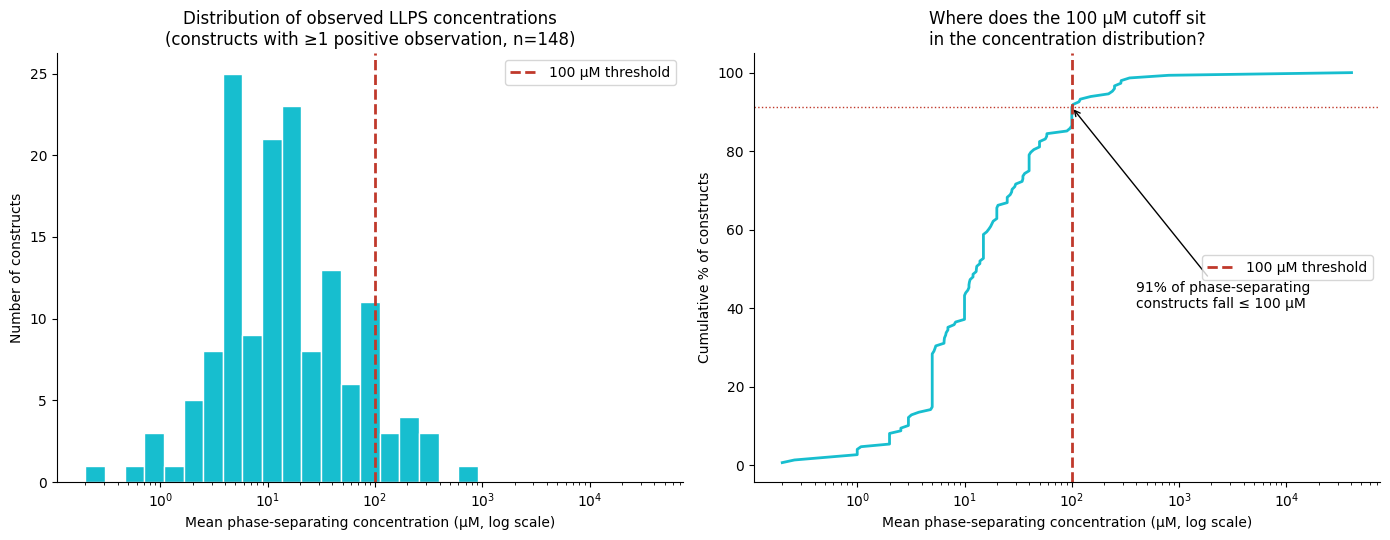

In [22]:
"""
Threshold Justification Analysis
=================================
Question: What is the basis for the 100 uM cutoff used to split
LLPSDB constructs into LLPS+ (high propensity) vs LLPS- (low
propensity)?

This script reconstructs the per-construct mean phase-separating
concentration distribution from the raw, cleaned LLPSDB table
(the same intermediate table produced during dataset generation,
before the LLPS+/LLPS- split is applied) and examines where the
100 uM cutoff actually falls within it.

Input:  _intermediate_cleaned_llpsdb.pkl
        (the cleaned/filtered LLPSDB table, with parsed
        'conc_uM_final' concentrations, saved during Step 1 of
        dataset generation -- see 01_build_llps_plus_minus.py)

Output: threshold_justification.png
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1) Load the cleaned LLPSDB table and isolate every construct
#    that had AT LEAST ONE positive ("Yes") phase-separation
#    observation, then average concentration per construct --
#    this is exactly the quantity the paper's 100 uM rule is
#    applied to.
# ---------------------------------------------------------------
df = pd.read_pickle('_intermediate_cleaned_llpsdb.pkl')

df_yes = df[df['Phase separation'] == 'Yes']
grouped = df_yes.groupby('Construct_sequence')['conc_uM_final'].mean()
grouped = grouped[grouped > 0]  # drop non-positive values (invalid for log scale)

print(f"Constructs with >=1 positive phase-separation observation: {len(grouped)}")
print(grouped.describe())

pct_below_threshold = (grouped <= 100).mean() * 100
print(f"\n{pct_below_threshold:.1f}% of these constructs phase-separate at <= 100 uM")

# ---------------------------------------------------------------
# 2) Plot A: log-scale histogram of the concentration distribution,
#    with the 100 uM cutoff marked
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
bins = np.logspace(np.log10(grouped.min()), np.log10(grouped.max()), 30)
ax.hist(grouped, bins=bins, color='#17becf', edgecolor='white')
ax.axvline(100, color='#c0392b', linestyle='--', linewidth=2, label='100 µM threshold')
ax.set_xscale('log')
ax.set_xlabel('Mean phase-separating concentration (µM, log scale)')
ax.set_ylabel('Number of constructs')
ax.set_title(f'Distribution of observed LLPS concentrations\n(constructs with ≥1 positive observation, n={len(grouped)})')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---------------------------------------------------------------
# 3) Plot B: cumulative distribution, showing what percentile
#    of the (positive-observation) population the 100 uM cutoff
#    corresponds to
# ---------------------------------------------------------------
ax = axes[1]
sorted_vals = np.sort(grouped.values)
cum_frac = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals) * 100
ax.plot(sorted_vals, cum_frac, color='#17becf', linewidth=2)
ax.axvline(100, color='#c0392b', linestyle='--', linewidth=2, label='100 µM threshold')
ax.axhline(pct_below_threshold, color='#c0392b', linestyle=':', linewidth=1)
ax.annotate(
    f'{pct_below_threshold:.0f}% of phase-separating\nconstructs fall ≤ 100 µM',
    xy=(100, pct_below_threshold), xytext=(400, 40),
    arrowprops=dict(arrowstyle='->', color='black'), fontsize=10,
)
ax.set_xscale('log')
ax.set_xlabel('Mean phase-separating concentration (µM, log scale)')
ax.set_ylabel('Cumulative % of constructs')
ax.set_title('Where does the 100 µM cutoff sit\nin the concentration distribution?')
ax.legend(loc='center right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig('threshold_justification.png', dpi=200, bbox_inches='tight')
print("\nSaved threshold_justification.png")